<a href="https://colab.research.google.com/github/MiKecantdothis/SPRLAB/blob/main/2448553_SPR_LAB4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Loaded signal with 381591 samples at 48000 Hz


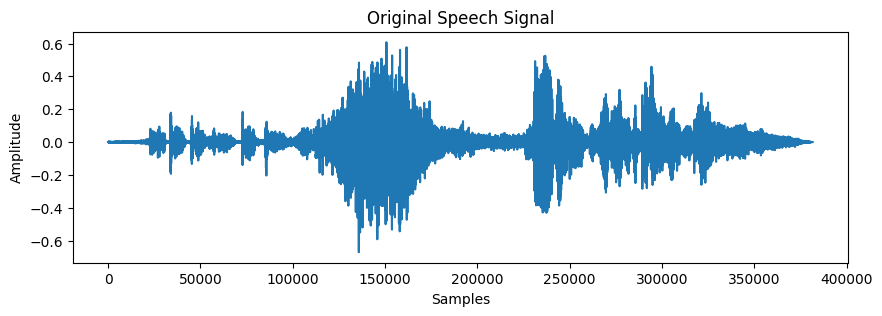

In [1]:
import librosa
import matplotlib.pyplot as plt

filename = "/content/audio.wav"  # e.g., "hello.wav"
signal, sr = librosa.load(filename, sr=None)

print(f"Loaded signal with {len(signal)} samples at {sr} Hz")

plt.figure(figsize=(10, 3))
plt.plot(signal)
plt.title("Original Speech Signal")
plt.xlabel("Samples")
plt.ylabel("Amplitude")
plt.show()


In [2]:
lpc_order = 12  # typical order for 16kHz speech
lpc_coeffs = librosa.lpc(signal, order=lpc_order)

print("LPC Coefficients:\n", lpc_coeffs)

LPC Coefficients:
 [  1.          -0.80287766  -1.2444463    2.2757978   -0.5210357
  -4.717165    11.803441   -18.50262     22.626083   -22.79696
  18.344374   -10.9950285    3.5632677 ]


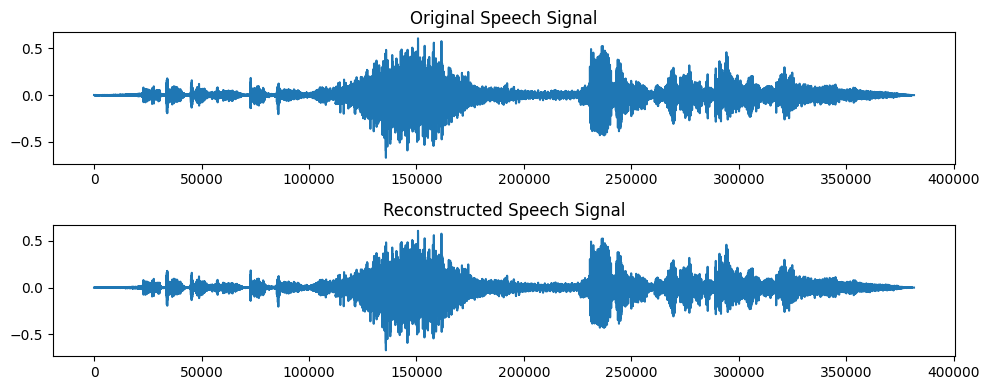

In [3]:
from scipy.signal import lfilter

# Compute residual (excitation)
residual = lfilter(lpc_coeffs, [1], signal)

# Reconstruct speech from LPC coefficients and residual
reconstructed = lfilter([1], lpc_coeffs, residual)

plt.figure(figsize=(10, 4))
plt.subplot(2, 1, 1)
plt.plot(signal)
plt.title("Original Speech Signal")
plt.subplot(2, 1, 2)
plt.plot(reconstructed)
plt.title("Reconstructed Speech Signal")
plt.tight_layout()
plt.show()


In [4]:
# Find roots of LPC polynomial
rts = np.roots(lpc_coeffs)
rts = [r for r in rts if np.imag(r) >= 0.01]  # Keep one side of the spectrum

# Convert to frequencies
angles = np.angle(rts)
formant_freqs = sorted(angles * (sr / (2 * np.pi)))

print("Estimated Formant Frequencies (Hz):")
print(formant_freqs[:4])  # F1, F2, F3, F4 (approx)


Estimated Formant Frequencies (Hz):
[np.float32(407.57278), np.float32(4216.5146), np.float32(7842.675), np.float32(11225.598)]


In [5]:
vowel_table = {
    '/a/': [730, 1090, 2440],
    '/e/': [530, 1840, 2480],
    '/i/': [270, 2290, 3010],
    '/o/': [570, 840, 2410],
    '/u/': [300, 870, 2240]
}

print("\n--- Comparison with Standard Formants ---")
for vowel, formants in vowel_table.items():
    diff = [abs(formant_freqs[i] - formants[i]) for i in range(3)]
    print(f"{vowel} → Estimated: {formant_freqs[:3]} | Difference: {np.round(diff, 2)}")



--- Comparison with Standard Formants ---
/a/ → Estimated: [np.float32(407.57278), np.float32(4216.5146), np.float32(7842.675)] | Difference: [ 322.43 3126.51 5402.68]
/e/ → Estimated: [np.float32(407.57278), np.float32(4216.5146), np.float32(7842.675)] | Difference: [ 122.43 2376.51 5362.68]
/i/ → Estimated: [np.float32(407.57278), np.float32(4216.5146), np.float32(7842.675)] | Difference: [ 137.57 1926.51 4832.67]
/o/ → Estimated: [np.float32(407.57278), np.float32(4216.5146), np.float32(7842.675)] | Difference: [ 162.43 3376.51 5432.68]
/u/ → Estimated: [np.float32(407.57278), np.float32(4216.5146), np.float32(7842.675)] | Difference: [ 107.57 3346.51 5602.68]
